In [2]:
import sys
import os

# Check Python version
print(f"Python Version: `{sys.version}`")  # Detailed version info
print(f"Base Python location: `{sys.base_prefix}`")
print(f"Current Environment location: `{os.path.basename(sys.prefix)}`", end='\n\n')

Python Version: `3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]`
Base Python location: `C:\Users\LMT\AppData\Local\Programs\Python\Python312`
Current Environment location: `.venv`



In [3]:
import pandas as pd
import os


In [5]:
df

,ItinID,MktID,MktCoupons,Year,Quarter,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCountry,...,BulkFare,Passengers,MktFare,MktDistance,MktDistanceGroup,MktMilesFlown,NonStopMiles,ItinGeoType,MktGeoType,Unnamed: 41
0,202313005808,20231300580803,2,2023,1,14843,1484306,34819,SJU,US,...,0.0,1.0,176.50,2412.0,5,2412.0,1319.0,1,1,NaN
1,202313005809,20231300580901,1,2023,1,13577,1357702,31135,MYR,US,...,0.0,4.0,6.00,636.0,2,636.0,636.0,2,2,NaN
2,202313005810,20231300581001,1,2023,1,13577,1357702,31135,MYR,US,...,0.0,2.0,15.00,636.0,2,636.0,636.0,2,2,NaN
3,202313005811,20231300581101,1,2023,1,13577,1357702,31135,MYR,US,...,0.0,1.0,16.00,636.0,2,636.0,636.0,2,2,NaN
4,202313005812,20231300581201,1,2023,1,13577,1357702,31135,MYR,US,...,0.0,5.0,17.00,636.0,2,636.0,636.0,2,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6714108,202311504891,20231150489101,2,2023,1,14524,1452401,34524,RIC,US,...,0.0,1.0,215.58,1711.0,4,1711.0,805.0,2,2,NaN
6714109,202311504891,20231150489103,1,2023,1,11697,1169706,32467,FLL,US,...,0.0,1.0,101.42,805.0,2,805.0,805.0,2,2,NaN
6714110,202311504892,20231150489201,2,2023,1,14524,1452401,34524,RIC,US,...,0.0,1.0,219.66,1711.0,4,1711.0,805.0,2,2,NaN
6714111,202311504892,20231150489203,1,2023,1,11697,1169706,32467,FLL,US,...,0.0,1.0,103.34,805.0,2,805.0,805.0,2,2,NaN


In [7]:
# Key columns for price prediction
key_columns = [
    'ItinID',           # Unique itinerary ID
    'MktID',            # Market ID
    'MktCoupons',       # Number of flight segments in this market
    'Year',             # Year
    'Quarter',          # Quarter (1-4)
    'Origin',           # Origin airport code
    'OriginStateName',  # Origin state
    'Dest',             # Destination airport code
    'DestStateName',    # Destination state
    'AirportGroup',     # Airports visited in order
    'TkCarrier',        # Ticketing carrier code
    'OpCarrier',        # Operating carrier code
    'RPCarrier',        # Reporting carrier code
    'Passengers',       # Number of passengers
    'MktFare',          # Market fare (price paid)
    'MktDistance',       # Market distance in miles
    'MktDistanceGroup', # Distance group
    'MktMilesFlown',    # Actual miles flown
    'NonStopMiles',     # Direct distance
    'BulkFare',         # Whether bulk fare (1=yes)
    # 'FarePerMile',      # Fare divided by distance
]

df_clean = df[key_columns].copy()
print(f"Clean dataset shape: {df_clean.shape}")
df_clean.describe()


Clean dataset shape: (6714113, 20)


,ItinID,MktID,MktCoupons,Year,Quarter,Passengers,MktFare,MktDistance,MktDistanceGroup,MktMilesFlown,NonStopMiles,BulkFare
count,6.714113e+06,6.714113e+06,6.714113e+06,6714113.0,6714113.0,6.714113e+06,6.714113e+06,6.714113e+06,6.714113e+06,6.714113e+06,6.714113e+06,6.714113e+06
mean,1.729971e+11,1.729971e+13,1.473328e+00,2023.0,1.0,2.006537e+00,2.749179e+02,1.327796e+03,3.156069e+00,1.324966e+03,1.243014e+03,8.325746e-05
std,6.745995e+10,6.745995e+12,5.459168e-01,0.0,0.0,6.175714e+00,7.936691e+02,8.290688e+02,1.685635e+00,8.278693e+02,7.831715e+02,9.124173e-03
min,2.023155e+06,2.023155e+08,1.000000e+00,2023.0,1.0,1.000000e+00,0.000000e+00,3.100000e+01,1.000000e+00,0.000000e+00,3.100000e+01,0.000000e+00
25%,2.023115e+11,2.023115e+13,1.000000e+00,2023.0,1.0,1.000000e+00,1.482700e+02,7.450000e+02,2.000000e+00,7.430000e+02,6.800000e+02,0.000000e+00
50%,2.023129e+11,2.023129e+13,1.000000e+00,2023.0,1.0,1.000000e+00,2.310000e+02,1.111000e+03,3.000000e+00,1.109000e+03,1.046000e+03,0.000000e+00
75%,2.023143e+11,2.023143e+13,2.000000e+00,2023.0,1.0,1.000000e+00,3.405000e+02,1.754000e+03,4.000000e+00,1.753000e+03,1.651000e+03,0.000000e+00
max,2.023154e+11,2.023154e+13,9.000000e+00,2023.0,1.0,1.120000e+03,1.345400e+06,1.138700e+04,2.300000e+01,1.138700e+04,8.373000e+03,1.000000e+00


In [8]:
# Filter for usable records
df_filtered = df_clean[
    (df_clean['MktFare'] > 0) &            # Remove zero fares
    (df_clean['MktFare'] < 10000) &         # Remove extreme outliers
    (df_clean['BulkFare'] == 0) &           # Remove bulk/contract fares
    (df_clean['Passengers'] > 0)            # Remove empty records
].copy()

print(f"Before filtering: {len(df_clean):,}")
print(f"After filtering:  {len(df_filtered):,}")
print(f"Removed: {len(df_clean) - len(df_filtered):,}")

print(f"\nPrice Statistics:")
print(f"  Mean:   ${df_filtered['MktFare'].mean():.2f}")
print(f"  Median: ${df_filtered['MktFare'].median():.2f}")
print(f"  Min:    ${df_filtered['MktFare'].min():.2f}")
print(f"  Max:    ${df_filtered['MktFare'].max():.2f}")


Before filtering: 6,714,113
After filtering:  6,707,311
Removed: 6,802

Price Statistics:
  Mean:   $274.40
  Median: $231.00
  Min:    $0.10
  Max:    $9986.00


In [ ]:
def load_multiple_quarters(data_dir: str, years: list, quarters: list) -> pd.DataFrame:
    """Load and combine multiple quarters of DB1B Market data."""
    frames = []
    
    for year in years:
        for quarter in quarters:
            pattern = f"Origin_and_Destination_Survey_DB1BMarket_{year}_{quarter}.csv"
            filepath = os.path.join(data_dir, pattern)
            
            if os.path.exists(filepath):
                print(f"Loading {year} Q{quarter}...")
                df = pd.read_csv(filepath, low_memory=False)
                frames.append(df)
            else:
                print(f"Missing: {year} Q{quarter}")
    
    if frames:
        combined = pd.concat(frames, ignore_index=True)
        print(f"\nTotal records: {len(combined):,}")
        return combined
    
    return pd.DataFrame()


# Load 2 years of data
df_all = load_multiple_quarters(
    data_dir="data/bts",
    years=[2023, 2024],
    quarters=[1, 2, 3, 4]
)


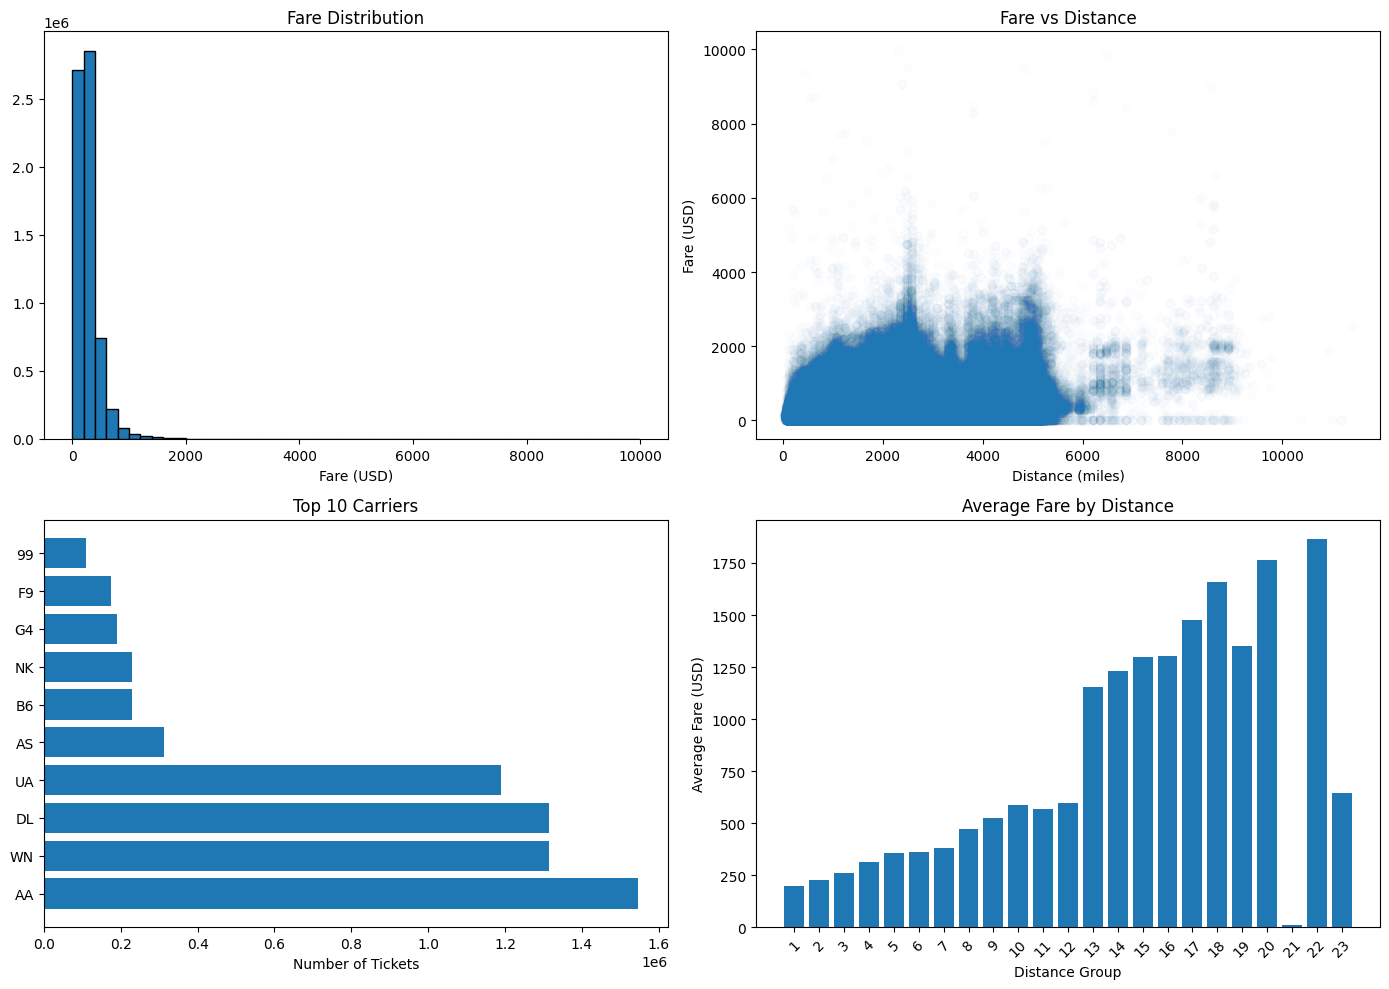

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
axes[0, 0].hist(df_filtered['MktFare'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Fare (USD)')
axes[0, 0].set_title('Fare Distribution')

# Fare vs Distance
axes[0, 1].scatter(df_filtered['MktDistance'], df_filtered['MktFare'], alpha=0.01)
axes[0, 1].set_xlabel('Distance (miles)')
axes[0, 1].set_ylabel('Fare (USD)')
axes[0, 1].set_title('Fare vs Distance')

# Top 10 carriers by volume
top_carriers = df_filtered['TkCarrier'].value_counts().head(10)
axes[1, 0].barh(top_carriers.index, top_carriers.values)
axes[1, 0].set_xlabel('Number of Tickets')
axes[1, 0].set_title('Top 10 Carriers')

# Average fare by distance group
avg_by_dist = df_filtered.groupby('MktDistanceGroup')['MktFare'].mean()
axes[1, 1].bar(avg_by_dist.index.astype(str), avg_by_dist.values)
axes[1, 1].set_xlabel('Distance Group')
axes[1, 1].set_ylabel('Average Fare (USD)')
axes[1, 1].set_title('Average Fare by Distance')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
def engineer_bts_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create ML features from BTS DB1B Market data."""
    features = df.copy()
    
    # Route identifier
    features['route'] = features['Origin'] + '_' + features['Dest']
    
    # Competition: number of carriers on route
    carrier_counts = features.groupby('route')['TkCarrier'].nunique()
    features['route_competition'] = features['route'].map(carrier_counts)
    
    # Carrier market share on route
    route_carrier = features.groupby(['route', 'TkCarrier'])['Passengers'].sum()
    route_total = features.groupby('route')['Passengers'].sum()
    market_share = (route_carrier / route_total).rename('carrier_market_share')
    features = features.merge(
        market_share.reset_index(),
        on=['route', 'TkCarrier'],
        how='left'
    )
    
    # Fare per mile
    features['fare_per_mile'] = features['MktFare'] / features['MktDistance'].clip(lower=1)
    
    # Is connecting flight
    features['is_connecting'] = (features['MktCoupons'] > 1).astype(int)
    
    # Route distance category
    features['distance_category'] = pd.cut(
        features['MktDistance'],
        bins=[0, 500, 1000, 2000, 5000, 20000],
        labels=['short', 'medium', 'long', 'very_long', 'ultra_long']
    )
    
    # Seasonal indicator
    features['season'] = features['Quarter'].map({
        1: 'winter', 2: 'spring', 3: 'summer', 4: 'fall'
    })
    
    return features


df_features = engineer_bts_features(df_filtered)
print(f"Features created: {df_features.shape[1]} columns")
print(f"Records: {df_features.shape[0]:,}")


Features created: 27 columns
Records: 6,707,311


: 

In [1]:
import pyarrow.parquet as pq

# Read metadata only (zero memory cost)
pf = pq.ParquetFile("data/bts/DB1C.PUBLIC.202507.REL01.03FEB2026.parquet")

print(f"Rows: {pf.metadata.num_rows:,}")
print(f"Columns: {pf.metadata.num_columns}")
print(f"Row groups: {pf.metadata.num_row_groups}")

# See column names and types
print("\nSchema:")
print(pf.schema_arrow)


Rows: 14,637,643
Columns: 288
Row groups: 147

Schema:
RpCarrier: string
RpYear: int16 not null
RpMonth: int8 not null
CouponSeg: int8
IssueCarrier: string
TotalAmt: double
TaxAmt: double
DollarCred: int64
NumPax: int32
PurWinGrp: string
SchFlYr_1: int16
SchFlMo_1: int8
Apt_1: string
WAC_1: int16
CityMktID_1: int32
ViaApt_1: string
OpCarrier_1: string
MktCarrier_1: string
SchFlYr_2: int16
SchFlMo_2: int8
Apt_2: string
Coupon_SegDist_1: int32
Dwell_Time_2: double
TripBk19_7_2: string
TripBk19_8_2: string
CityMktID_2: int32
CityWAC_2: int16
ViaApt_2: string
OpCarrier_2: string
MktCarrier_2: string
SchFlYr_3: int16
SchFlMo_3: int8
Apt_3: string
Coupon_SegDist_2: int32
Dwell_Time_3: double
TripBk19_7_3: string
TripBk19_8_3: string
CityMktID_3: int32
CityWAC_3: int16
ViaApt_3: string
OpCarrier_3: string
MktCarrier_3: string
SchFlYr_4: int16
SchFlMo_4: int8
Apt_4: string
Coupon_SegDist_3: int32
Dwell_Time_4: double
TripBk19_7_4: string
TripBk19_8_4: string
CityMktID_4: int32
CityWAC_4: int16

In [4]:
import pyarrow.parquet as pq
import pandas as pd

# Only load columns relevant to price prediction
DB1C_COLUMNS = [
    'RpCarrier',
    'RpYear',
    'RpMonth',
    'CouponSeg',
    'IssueCarrier',
    'TotalAmt',
    'TaxAmt',
    'NumPax',
    'PurWinGrp',
    'Apt_1',          # Origin
    'MktCarrier_1',   # Marketing carrier
    'OpCarrier_1',    # Operating carrier
    'Coupon_SegDist_1',
    'Apt_2',          # First connection or destination
    'LastApt',        # Final destination
    'LastCityWAC',
]

df = pd.read_parquet(
    "data/bts/DB1C.PUBLIC.202507.REL01.03FEB2026.parquet",
    columns=DB1C_COLUMNS
)

print(f"Shape: {df.shape}")
mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memory: {mem_mb:.0f} MB")
df.head()


Shape: (14637643, 16)
Memory: 5933 MB


,RpCarrier,RpYear,RpMonth,CouponSeg,IssueCarrier,TotalAmt,TaxAmt,NumPax,PurWinGrp,Apt_1,MktCarrier_1,OpCarrier_1,Coupon_SegDist_1,Apt_2,LastApt,LastCityWAC
0,WN,2025,7,2,WN,426.96,58.25,1,21AP,DAL,WN,WN,1184.0,DCA,None,NaN
1,WN,2025,7,1,WN,5.60,5.60,1,2290,PHX,WN,WN,1788.0,TPA,None,NaN
2,WN,2025,7,2,WN,318.97,50.72,1,21AP,SLC,WN,WN,391.0,DEN,None,NaN
3,WN,2025,7,2,WN,346.96,52.67,1,2290,MCO,WN,WN,1011.0,BUF,None,NaN
4,WN,2025,7,4,WN,502.36,81.56,1,21AP,ROC,WN,WN,277.0,BWI,None,NaN


In [5]:
# Basic statistics
print(f"Rows: {len(df):,}")
print(f"\nPrice (TotalAmt):")
print(f"  Min:    ${df['TotalAmt'].min():.2f}")
print(f"  Max:    ${df['TotalAmt'].max():.2f}")
print(f"  Mean:   ${df['TotalAmt'].mean():.2f}")
print(f"  Median: ${df['TotalAmt'].median():.2f}")

print(f"\nPassengers: {df['NumPax'].sum():,}")
print(f"\nAdvance Purchase Groups:")
print(df['PurWinGrp'].value_counts())

print(f"\nTop 10 Routes:")
df['route'] = df['Apt_1'] + ' -> ' + df['LastApt']
print(df['route'].value_counts().head(10))


Rows: 14,637,643

Price (TotalAmt):
  Min:    $0.00
  Max:    $17809.76
  Mean:   $334.15
  Median: $276.19

Passengers: 14,637,643

Advance Purchase Groups:
PurWinGrp
21AP    6964237
2290    6032435
91UP    1640971
Name: count, dtype: int64

Top 10 Routes:
Series([], Name: count, dtype: int64)
